In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, loggamma, kv

np.set_printoptions(precision=4, suppress=True)

In [2]:
# Parameters for z(t) = -ln(cosh t)
A = 1.0
kappa = 1.0
B = np.log(2.0)

# Mode grids
N = 10
omega = np.linspace(1, 10, N)
omega_p = np.linspace(1, 10, N)

omega_ = omega[:, None]
omega_p_ = omega_p[None, :]

In [3]:
def beta_davies(omega, omega_p, A, B, kappa):
    D = (1.0 / kappa) * np.log(A) - B
    
    omega_ = omega[:, None]
    omega_p_ = omega_p[None, :]
    
    log_pref = (
        -np.log(2*np.pi)
        -0.5*(np.log(omega_) + np.log(omega_p_))
        -np.pi * omega_p_/(2*kappa)
    )
    
    phase = (
        -1j * omega_p_ * D
        +1j * omega_ * B
        -1j * (omega_p_/kappa) * np.log(omega_)
    )
    
    lgamma = loggamma(1.0 + 1j*omega_p_/kappa)
    
    log_beta = log_pref + phase + lgamma
    
    # prevent overflow
    log_beta_real = np.clip(log_beta.real, -700, 700)
    
    beta = -1j * np.exp(log_beta_real) * np.exp(1j*log_beta.imag)
    
    return beta

beta_D = beta_davies(omega, omega_p, A, B, kappa)

beta_D

array([[ 0.0153-0.0081j,  0.0006+0.0004j, -0.    +0.j    ,
        -0.    -0.j    ,  0.    +0.j    , -0.    +0.j    ,
         0.    -0.j    ,  0.    +0.j    , -0.    -0.j    ,
         0.    +0.j    ],
       [ 0.0108-0.0057j,  0.0005-0.j    ,  0.    +0.j    ,
        -0.    +0.j    , -0.    -0.j    ,  0.    -0.j    ,
         0.    +0.j    , -0.    +0.j    ,  0.    -0.j    ,
         0.    +0.j    ],
       [ 0.0098-0.002j ,  0.0004-0.0001j,  0.    +0.j    ,
         0.    +0.j    , -0.    +0.j    , -0.    -0.j    ,
         0.    -0.j    ,  0.    +0.j    , -0.    +0.j    ,
        -0.    -0.j    ],
       [ 0.0084+0.0018j,  0.0004-0.j    ,  0.    +0.j    ,
         0.    +0.j    ,  0.    +0.j    , -0.    +0.j    ,
        -0.    -0.j    ,  0.    -0.j    ,  0.    +0.j    ,
        -0.    +0.j    ],
       [ 0.006 +0.0048j,  0.0003+0.0001j,  0.    +0.j    ,
         0.    +0.j    ,  0.    +0.j    , -0.    +0.j    ,
        -0.    +0.j    , -0.    -0.j    ,  0.    -0.j    ,
         0.

In [4]:
import mpmath as mp

def beta_good(omega, omega_p, kappa):

    beta = np.zeros((len(omega), len(omega_p)), dtype=np.complex128)

    for i, w in enumerate(omega):
        for j, wp in enumerate(omega_p):

            pref = -np.sqrt(w * wp) / (np.pi * kappa * wp)
            thermal = np.exp(-np.pi * w / (2*kappa))

            K = mp.besselk(1j*w/kappa, wp/kappa)

            beta[i,j] = pref * thermal * complex(K)

    return beta

beta_G = beta_good(omega, omega_p, kappa)
beta_G

array([[-0.0192+0.j, -0.0043+0.j, -0.0011+0.j, -0.0003+0.j, -0.0001+0.j,
        -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j],
       [-0.0016+0.j, -0.0007+0.j, -0.0002+0.j, -0.0001+0.j, -0.    +0.j,
        -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j],
       [ 0.    -0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j,
        -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j],
       [ 0.    -0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j,
        -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j],
       [-0.    +0.j,  0.    -0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j,
        -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j],
       [ 0.    -0.j,  0.    -0.j,  0.    -0.j, -0.    +0.j, -0.    +0.j,
        -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j, -0.    +0.j],
       [ 0.    -0.j, -0.    +0.j,  0.    -0.j, -0.    +0.j, -0.    +0.j,
        -0.    +0.j, -0.    +0.j, -0.    +0.j

In [5]:
np.abs(beta_G - beta_D)

array([[0.0353, 0.0049, 0.0011, 0.0003, 0.0001, 0.    , 0.    , 0.    ,
        0.    , 0.    ],
       [0.0136, 0.0012, 0.0002, 0.0001, 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    ],
       [0.01  , 0.0005, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    ],
       [0.0086, 0.0004, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    ],
       [0.0077, 0.0003, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    ],
       [0.007 , 0.0003, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    ],
       [0.0065, 0.0003, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    ],
       [0.0061, 0.0003, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    ],
       [0.0058, 0.0002, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    ],
       [0.0055, 0.0002, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    ]])

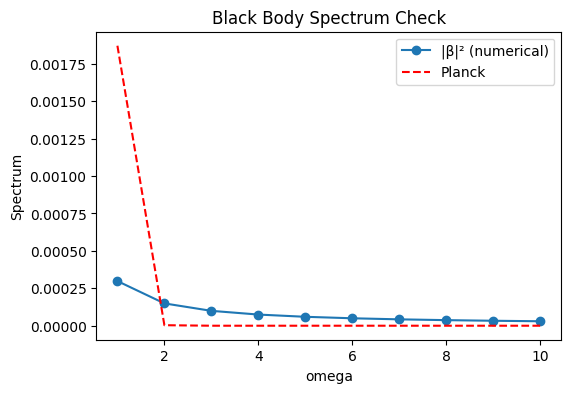

In [6]:
# compute particle spectrum by summing over omega'
spectrum = np.sum(np.abs(beta_D)**2, axis=1)

# theoretical Planck spectrum
planck = 1.0 / (np.exp(2*np.pi*omega/kappa) - 1)

plt.figure(figsize=(6,4))
plt.plot(omega, spectrum, 'o-', label="|β|² (numerical)")
plt.plot(omega, planck, 'r--', label="Planck")
plt.xlabel("omega")
plt.ylabel("Spectrum")
plt.legend()
plt.title("Black Body Spectrum Check")
plt.show()

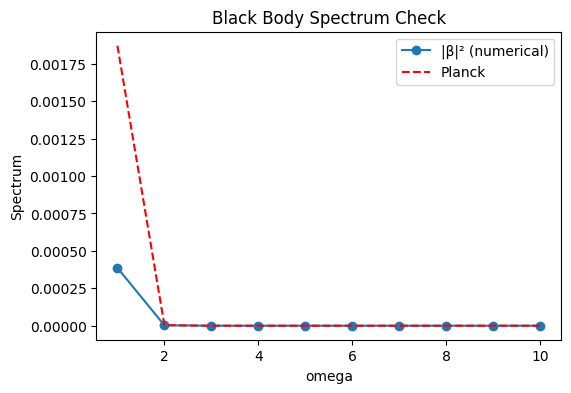

In [7]:
# compute particle spectrum by summing over omega'
spectrum = np.sum(np.abs(beta_G)**2, axis=1)

# theoretical Planck spectrum
planck = 1.0 / (np.exp(2*np.pi*omega/kappa) - 1)

plt.figure(figsize=(6,4))
plt.plot(omega, spectrum, 'o-', label="|β|² (numerical)")
plt.plot(omega, planck, 'r--', label="Planck")
plt.xlabel("omega")
plt.ylabel("Spectrum")
plt.legend()
plt.title("Black Body Spectrum Check")
plt.show()

In [8]:
# Parameters for z(t) = -ln(cosh t)
A = 1.0
kappa = 1.0
B = np.log(2.0)

# Mode grids
N = 10
omega = np.linspace(0.1, 2, N)
omega_p = np.linspace(0.1, 2, N)

omega_ = omega[:, None]
omega_p_ = omega_p[None, :]

In [9]:
beta_D = beta_davies(omega, omega_p, A, B, kappa)
beta_D

array([[ 0.4136-1.2841j,  0.3792-0.3446j,  0.2449-0.0466j,
         0.1167+0.0491j,  0.0339+0.0555j, -0.0037+0.0332j,
        -0.0124+0.0119j, -0.0089+0.0004j, -0.0035-0.003j ,
        -0.0002-0.0023j],
       [ 0.2582-0.7199j,  0.1703-0.2353j,  0.1138-0.0838j,
         0.0688-0.0204j,  0.0367+0.0036j,  0.0165+0.0094j,
         0.0055+0.0081j,  0.0006+0.005j , -0.001 +0.0024j,
        -0.0011+0.0008j],
       [ 0.2509-0.5344j,  0.1288-0.1836j,  0.0792-0.0751j,
         0.048 -0.0276j,  0.0276-0.0069j,  0.0146+0.001j ,
         0.0069+0.003j ,  0.0028+0.0027j,  0.0008+0.0019j,
        -0.    +0.001j ],
       [ 0.261 -0.4244j,  0.1149-0.1504j,  0.0648-0.0654j,
         0.0379-0.0273j,  0.0219-0.0098j,  0.0122-0.0022j,
         0.0063+0.0006j,  0.003 +0.0013j,  0.0013+0.0011j,
         0.0004+0.0008j],
       [ 0.2734-0.3434j,  0.1099-0.1253j,  0.0579-0.0568j,
         0.0325-0.0254j,  0.0184-0.0104j,  0.0103-0.0035j,
         0.0056-0.0006j,  0.0029+0.0004j,  0.0014+0.0006j,
         0.

In [10]:
beta_G = beta_good(omega, omega_p, kappa)
beta_G

array([[-0.6495+0.j, -0.2048+0.j, -0.1052+0.j, -0.0627+0.j, -0.0402+0.j,
        -0.027 +0.j, -0.0187+0.j, -0.0132+0.j, -0.0095+0.j, -0.0069+0.j],
       [-0.711 +0.j, -0.2409+0.j, -0.1264+0.j, -0.0762+0.j, -0.0493+0.j,
        -0.0332+0.j, -0.0231+0.j, -0.0164+0.j, -0.0118+0.j, -0.0086+0.j],
       [-0.4832+0.j, -0.1922+0.j, -0.1057+0.j, -0.0652+0.j, -0.0428+0.j,
        -0.0292+0.j, -0.0204+0.j, -0.0145+0.j, -0.0105+0.j, -0.0077+0.j],
       [-0.24  +0.j, -0.1285+0.j, -0.0763+0.j, -0.0489+0.j, -0.0328+0.j,
        -0.0227+0.j, -0.0161+0.j, -0.0116+0.j, -0.0084+0.j, -0.0062+0.j],
       [-0.0753+0.j, -0.0742+0.j, -0.0495+0.j, -0.0335+0.j, -0.0232+0.j,
        -0.0164+0.j, -0.0118+0.j, -0.0086+0.j, -0.0063+0.j, -0.0047+0.j],
       [ 0.0029-0.j, -0.0365+0.j, -0.0291+0.j, -0.0213+0.j, -0.0154+0.j,
        -0.0112+0.j, -0.0082+0.j, -0.0061+0.j, -0.0045+0.j, -0.0034+0.j],
       [ 0.0232-0.j, -0.0142+0.j, -0.0154+0.j, -0.0125+0.j, -0.0096+0.j,
        -0.0073+0.j, -0.0055+0.j, -0.0041+0.j

In [11]:
np.abs(beta_G - beta_D)

array([[1.6671, 0.6781, 0.3531, 0.186 , 0.0926, 0.0406, 0.0135, 0.0044,
        0.0067, 0.0071],
       [1.2074, 0.4738, 0.2544, 0.1465, 0.086 , 0.0506, 0.0297, 0.0177,
        0.0111, 0.0076],
       [0.908 , 0.3697, 0.1995, 0.1166, 0.0707, 0.0438, 0.0275, 0.0175,
        0.0114, 0.0077],
       [0.6566, 0.2861, 0.1555, 0.091 , 0.0556, 0.0349, 0.0224, 0.0146,
        0.0098, 0.0067],
       [0.4894, 0.2228, 0.1215, 0.0707, 0.0429, 0.027 , 0.0174, 0.0115,
        0.0077, 0.0053],
       [0.3948, 0.1788, 0.0969, 0.0556, 0.0332, 0.0206, 0.0132, 0.0087,
        0.0058, 0.004 ],
       [0.3467, 0.15  , 0.08  , 0.0449, 0.0262, 0.0159, 0.01  , 0.0065,
        0.0044, 0.003 ],
       [0.3244, 0.1317, 0.0687, 0.0377, 0.0214, 0.0126, 0.0077, 0.0049,
        0.0032, 0.0022],
       [0.3121, 0.1203, 0.0613, 0.0329, 0.0181, 0.0103, 0.0061, 0.0038,
        0.0024, 0.0016],
       [0.3009, 0.1129, 0.0563, 0.0296, 0.016 , 0.0088, 0.005 , 0.003 ,
        0.0018, 0.0012]])

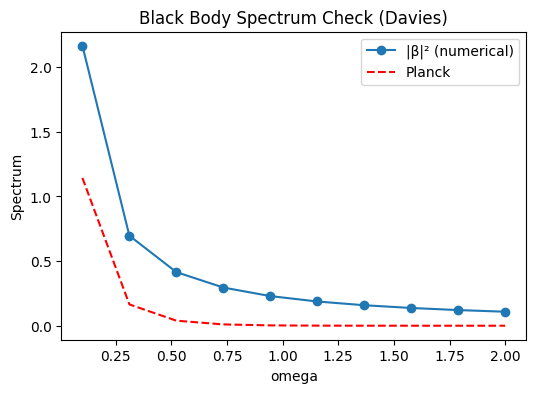

In [12]:
# compute particle spectrum by summing over omega'
spectrum = np.sum(np.abs(beta_D)**2, axis=1)

# theoretical Planck spectrum
planck = 1.0 / (np.exp(2*np.pi*omega/kappa) - 1)

plt.figure(figsize=(6,4))
plt.plot(omega, spectrum, 'o-', label="|β|² (numerical)")
plt.plot(omega, planck, 'r--', label="Planck")
plt.xlabel("omega")
plt.ylabel("Spectrum")
plt.legend()
plt.title("Black Body Spectrum Check (Davies)")
plt.show()

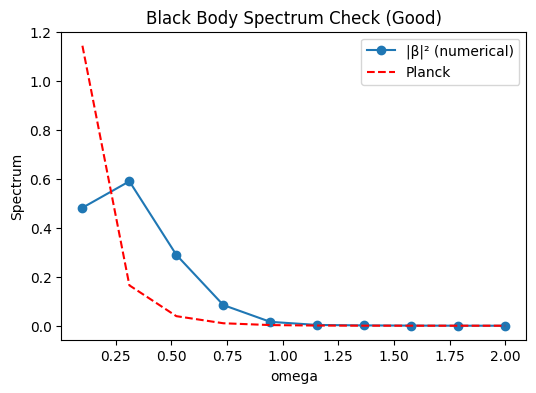

In [13]:
# compute particle spectrum by summing over omega'
spectrum = np.sum(np.abs(beta_G)**2, axis=1)

# theoretical Planck spectrum
planck = 1.0 / (np.exp(2*np.pi*omega/kappa) - 1)

plt.figure(figsize=(6,4))
plt.plot(omega, spectrum, 'o-', label="|β|² (numerical)")
plt.plot(omega, planck, 'r--', label="Planck")
plt.xlabel("omega")
plt.ylabel("Spectrum")
plt.legend()
plt.title("Black Body Spectrum Check (Good)")
plt.show()

In [14]:
N = 100
omega = np.linspace(0.0001, 2, N)
omega_p = np.linspace(0.0001, 2, N)

omega_ = omega[:, None]
omega_p_ = omega_p[None, :]

beta_G = beta_davies(omega, omega_p, A, B, kappa)
beta_G

array([[ 1.5944-1591.2986j, 20.3637 -106.2253j, 27.3387  -68.8812j, ...,
         0.0518   -0.0669j,  0.0608   -0.051j ,  0.066    -0.0346j],
       [ 1.6163 -111.6728j,  0.7242   -7.5565j,  0.9139   -5.1203j, ...,
         0.0018   +0.0056j,  0.0011   +0.0055j,  0.0005   +0.0052j],
       [ 2.2458  -79.0384j,  0.5126   -5.3499j,  0.5963   -3.6338j, ...,
         0.0042   -0.0003j,  0.0039   +0.j    ,  0.0037   +0.0004j],
       ...,
       [11.1117   -2.3982j,  0.7534   -0.1715j,  0.5148   -0.1233j, ...,
         0.0006   -0.j    ,  0.0006   -0.j    ,  0.0005   -0.j    ],
       [11.0872   -2.2309j,  0.7518   -0.1603j,  0.5138   -0.1157j, ...,
         0.0006   -0.j    ,  0.0006   -0.j    ,  0.0005   -0.j    ],
       [11.0611   -2.0649j,  0.7501   -0.1491j,  0.5127   -0.1081j, ...,
         0.0006   -0.j    ,  0.0006   -0.j    ,  0.0005   -0.j    ]],
      shape=(100, 100))

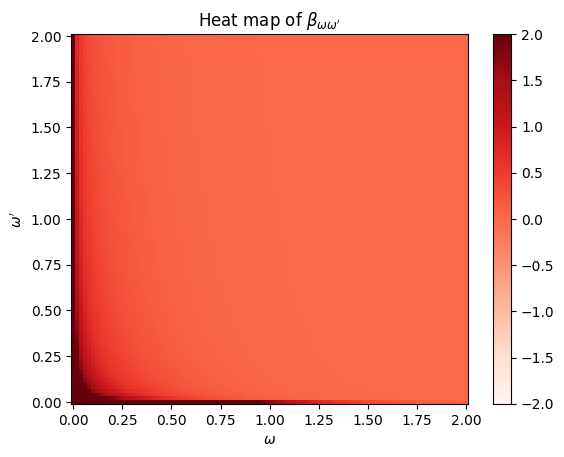

In [15]:
pc = plt.pcolormesh(omega, omega_p, np.abs(beta_G), cmap='Reds', vmin=-2, vmax=2)
plt.colorbar(pc)
plt.xlabel(r'$\omega$')
plt.ylabel(r"$\omega'$")
plt.title(r"Heat map of $\beta_{\omega \omega'}$")
plt.show()

In [18]:
N = 10
omega = np.linspace(1, 10, N)
omega_p = np.linspace(1, 10, N)

omega_ = omega[:, None]
omega_p_ = omega_p[None, :]

beta = beta_davies(omega, omega_p, A, B, kappa)
10**omega * beta

array([[ 0.1526-0.0806j,  0.0598+0.0444j, -0.0204+0.0249j,
        -0.0068-0.0122j,  0.006 +0.0007j, -0.0021+0.0015j,
         0.0004-0.001j ,  0.    +0.0005j, -0.0001-0.0002j,
         0.    +0.0001j],
       [ 0.1079-0.057j ,  0.0526-0.0029j,  0.0147+0.0174j,
        -0.0052+0.0084j, -0.0038-0.002j ,  0.0011-0.0015j,
         0.0005+0.0006j, -0.0003+0.0001j,  0.0001-0.0001j,
         0.    +0.0001j],
       [ 0.0977-0.0196j,  0.0424-0.0074j,  0.0175+0.0063j,
         0.0029+0.0075j, -0.0023+0.0026j, -0.0013-0.0007j,
         0.0002-0.0006j,  0.0003+0.0001j, -0.0001+0.0001j,
        -0.    -0.j    ],
       [ 0.0844+0.0177j,  0.0372-0.002j ,  0.0158+0.0028j,
         0.0051+0.0047j,  0.0001+0.003j , -0.0011+0.0007j,
        -0.0005-0.0003j,  0.0001-0.0002j,  0.0001+0.j    ,
        -0.    +0.j    ],
       [ 0.0602+0.0483j,  0.0327+0.0064j,  0.0141+0.0029j,
         0.0053+0.0032j,  0.0011+0.0024j, -0.0004+0.0011j,
        -0.0005+0.0001j, -0.0001-0.0002j,  0.    -0.0001j,
         0.

In [21]:
np.abs(10**omega * beta).min()

np.float64(2.865144483141619e-05)